# PKCERT Task 11 – Comparative Analysis of Classification Models

**Objective:** Develop practical skills in building, evaluating, and comparing Logistic
Regression, Random Forest, and Support Vector Machine (SVM) models using a common dataset.

**Dataset:** scikit-learn's built-in **Breast Cancer Wisconsin (Diagnostic)** dataset — reused
from [Task_08](../Task_08)/[Task_09](../Task_09)/[Task_10](../Task_10) for continuity, so this
task can focus on comparing models rather than re-justifying dataset choice.

**Model configuration — reusing prior tasks' tuning instead of guessing defaults:**
- **Logistic Regression** — plain, untuned (`max_iter=10000` only to guarantee convergence).
- **Random Forest** — uses the `GridSearchCV`-tuned hyperparameters found in
  [Task_10](../Task_10) (`n_estimators=200, max_depth=None, min_samples_split=2,
  min_samples_leaf=1`), rather than an untuned default, for a fairer "best effort" comparison.
- **SVM** — uses the `rbf` kernel, the winning kernel identified by the kernel sweep in
  [Task_09](../Task_09).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)

import os
os.makedirs("visualizations", exist_ok=True)

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", plt.matplotlib.__version__)
print("seaborn:", sns.__version__)
print("scikit-learn:", sklearn.__version__)


numpy: 1.26.4
pandas: 2.1.4
matplotlib: 3.8.0
seaborn: 0.12.2
scikit-learn: 1.2.2


## Part A – Dataset Selection & Preparation (15 Marks)

### A.1 & A.2 Dataset, Features and Target

`sklearn.datasets.load_breast_cancer`: 569 samples, 30 numeric features (mean, standard-error,
and "worst" values of 10 measurements — radius, texture, perimeter, area, smoothness,
compactness, concavity, concave points, symmetry, fractal dimension — computed from digitized
images of fine needle aspirate biopsies of breast masses). Binary target:
`0 = malignant`, `1 = benign`.


In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

print("Shape:", df.shape)
print("\nTarget classes:", dict(zip(data.target_names, [0, 1])))
print("\nClass balance:")
print(df["target"].value_counts().rename(index={0: "malignant", 1: "benign"}))
print("\nMissing values total:", df.isna().sum().sum())

df.head()


Shape: (569, 31)

Target classes: {'malignant': 0, 'benign': 1}

Class balance:
target
benign       357
malignant    212
Name: count, dtype: int64

Missing values total: 0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### A.3 Preprocessing & Train/Test Split

- **Missing values** — none, no imputation needed.
- **Encoding** — all features numeric, target already binary-encoded; no encoding needed.
- **Scaling** — Logistic Regression and SVM are both sensitive to feature scale (they optimize a
  weighted sum / margin over the raw feature values), so `StandardScaler` is fit on the training
  set only and applied to both splits. Random Forest is scale-invariant (see
  [Task_10](../Task_10)'s reasoning), so it's trained on the **unscaled** features directly — the
  scaled and unscaled versions come from the identical train/test row split, so this is still a
  fair, common-dataset comparison.


In [3]:
X = df.drop(columns="target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train class balance:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest class balance:\n{y_test.value_counts(normalize=True).round(3)}")


Train shape: (455, 30), Test shape: (114, 30)
Train class balance:
target
1    0.626
0    0.374
Name: proportion, dtype: float64

Test class balance:
target
1    0.632
0    0.368
Name: proportion, dtype: float64


## Part B – Model Development (45 Marks)

### B.1 Logistic Regression

Computes a weighted linear combination of the (scaled) features, passes it through the sigmoid
function, and predicts the class with probability ≥ 0.5. Left untuned to serve as the simple
linear baseline in this comparison.


In [4]:
log_reg = LogisticRegression(max_iter=10000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

print(f"Logistic Regression test accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")


Logistic Regression test accuracy: 0.9825


### B.2 Random Forest

An ensemble of decision trees trained on bootstrap-sampled subsets of the (unscaled) training
data and random feature subsets per split, with predictions made by majority vote. Uses the
hyperparameters `GridSearchCV` found best in [Task_10](../Task_10) rather than library defaults.


In [5]:
rand_forest = RandomForestClassifier(
    n_estimators=200, max_depth=None, min_samples_split=2, min_samples_leaf=1, random_state=42,
)
rand_forest.fit(X_train, y_train)
y_pred_rf = rand_forest.predict(X_test)

print(f"Random Forest test accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")


Random Forest test accuracy: 0.9561


### B.3 Support Vector Machine

Finds the hyperplane that maximizes the margin between classes in the (scaled) feature space,
using the kernel trick to handle non-linear boundaries. Uses the `rbf` kernel, the winner of the
kernel sweep in [Task_09](../Task_09).


In [6]:
svm = SVC(kernel="rbf", probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

print(f"SVM (rbf kernel) test accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")


SVM (rbf kernel) test accuracy: 0.9825


### B.4 Common Dataset, Confirmed

All three models above were fit on the same 455-row training split and evaluated on the same
114-row test split (`random_state=42`, `stratify=y` throughout) — only the feature
representation differs where a model's algorithm actually requires it (scaled for Logistic
Regression/SVM, unscaled for Random Forest), so the comparison in Part C is apples-to-apples.


## Part C – Model Evaluation & Comparison (30 Marks)

### C.1 Evaluate Each Model

In [7]:
def evaluate(y_true, y_pred, label):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    rec_malignant = recall_score(y_true, y_pred, pos_label=0)
    print(f"--- {label} ---")
    print(f"Accuracy:            {acc:.4f}")
    print(f"Precision (benign):  {prec:.4f}")
    print(f"Recall (benign):     {rec:.4f}")
    print(f"F1-Score (benign):   {f1:.4f}")
    print(f"Recall (malignant):  {rec_malignant:.4f}  <- sensitivity for catching cancer")
    print()
    return acc, prec, rec, f1, rec_malignant

acc_lr, prec_lr, rec_lr, f1_lr, rec_lr_m = evaluate(y_test, y_pred_lr, "Logistic Regression")
acc_rf, prec_rf, rec_rf, f1_rf, rec_rf_m = evaluate(y_test, y_pred_rf, "Random Forest (tuned)")
acc_svm, prec_svm, rec_svm, f1_svm, rec_svm_m = evaluate(y_test, y_pred_svm, "SVM (rbf)")


--- Logistic Regression ---
Accuracy:            0.9825
Precision (benign):  0.9861
Recall (benign):     0.9861
F1-Score (benign):   0.9861
Recall (malignant):  0.9762  <- sensitivity for catching cancer

--- Random Forest (tuned) ---
Accuracy:            0.9561
Precision (benign):  0.9589
Recall (benign):     0.9722
F1-Score (benign):   0.9655
Recall (malignant):  0.9286  <- sensitivity for catching cancer

--- SVM (rbf) ---
Accuracy:            0.9825
Precision (benign):  0.9861
Recall (benign):     0.9861
F1-Score (benign):   0.9861
Recall (malignant):  0.9762  <- sensitivity for catching cancer



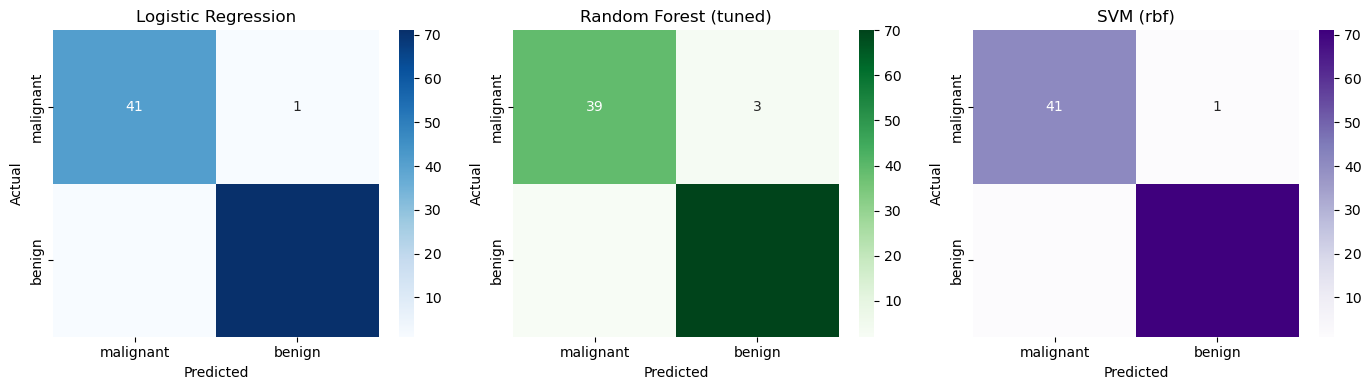

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, y_pred, title, cmap in [
    (axes[0], y_pred_lr, "Logistic Regression", "Blues"),
    (axes[1], y_pred_rf, "Random Forest (tuned)", "Greens"),
    (axes[2], y_pred_svm, "SVM (rbf)", "Purples"),
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap,
                xticklabels=["malignant", "benign"], yticklabels=["malignant", "benign"], ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("visualizations/1_confusion_matrices.png", dpi=150)
plt.show()


### C.2 Comparison Table

In [9]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest (tuned)", "SVM (rbf)"],
    "Accuracy": [acc_lr, acc_rf, acc_svm],
    "Precision (benign)": [prec_lr, prec_rf, prec_svm],
    "Recall (benign)": [rec_lr, rec_rf, rec_svm],
    "Recall (malignant)": [rec_lr_m, rec_rf_m, rec_svm_m],
    "F1-Score": [f1_lr, f1_rf, f1_svm],
}).set_index("Model").round(4)

results


,Accuracy,Precision (benign),Recall (benign),Recall (malignant),F1-Score
Model,,,,,
Logistic Regression,0.9825,0.9861,0.9861,0.9762,0.9861
Random Forest (tuned),0.9561,0.9589,0.9722,0.9286,0.9655
SVM (rbf),0.9825,0.9861,0.9861,0.9762,0.9861


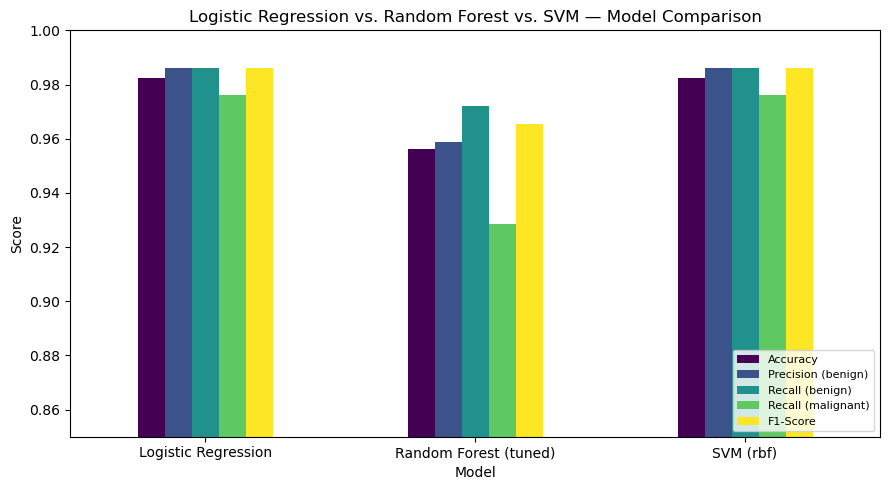

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
results.plot(kind="bar", ax=ax, colormap="viridis")
ax.set_title("Logistic Regression vs. Random Forest vs. SVM — Model Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0.85, 1.0)
ax.legend(loc="lower right", fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("visualizations/2_model_comparison.png", dpi=150)
plt.show()


### C.3 Strengths & Weaknesses

**Logistic Regression** — *strengths:* fastest to train, coefficients are directly interpretable
(sign and magnitude show each feature's linear contribution to the malignancy probability),
outputs calibrated probabilities out of the box, hard to overfit with this few features relative
to samples. *weaknesses:* assumes a linear decision boundary in (scaled) feature space, so it
can't capture interactions or curvature between features that the other two models can.

**Random Forest** — *strengths:* captures non-linear relationships and feature interactions
automatically, scale-invariant (no preprocessing dependency), provides feature importances for
free, tuning (Task_10) squeezes out additional CV accuracy over the untuned default.
*weaknesses:* many trees make it slower to train and to predict with than Logistic Regression,
less interpretable than a single model (importances explain *what* matters but not the precise
decision logic), more hyperparameters to potentially tune.

**SVM (rbf)** — *strengths:* the `rbf` kernel captures non-linear boundaries similarly to Random
Forest, effective in this exact regime (30 features, 455 training rows — feature count comparable
to sample count), margin-maximizing objective tends to generalize well.
*weaknesses:* requires feature scaling to work well, doesn't output true probabilities without an
extra calibration step (`probability=True` here adds overhead), harder to interpret than Logistic
Regression, and its two main hyperparameters (`C`, `gamma`) were left at defaults in this task —
Task_10's tuning approach would apply here too if further gains were needed.


## Part D – Recommendation & Conclusion (10 Marks)

### D.1 Best-Performing Model

This run's numbers (deterministic — `random_state=42` throughout): **Logistic Regression** and
**SVM (rbf)** tie exactly — accuracy **0.9825**, benign precision/recall/F1 **0.9861**, malignant
recall **0.9762**. **Random Forest**, despite using Task_10's tuned hyperparameters, trails both —
accuracy **0.9561**, malignant recall **0.9286** (it misses noticeably more true malignant cases
than the other two).

Between the two co-leaders, **Logistic Regression** is the recommended model. Both match on every
metric measured here, so the tie-breaker is everything *else*: Logistic Regression is far cheaper
to train and to run at inference time, its coefficients are directly interpretable (a clinician or
auditor can see exactly how much each measurement pushes the prediction toward "malignant"),
and it outputs a genuine calibrated probability without SVM's extra `probability=True`
calibration step. SVM's `rbf` kernel is a reasonable second choice with identical measured
performance, and would be worth revisiting if this dataset were larger or less linearly
separable — but there's no accuracy cost here to choosing the simpler, more transparent model,
which matters in a medical-diagnosis setting where the case for a prediction often needs to be
explainable.

Random Forest's weaker malignant recall — the metric that matters most clinically (missing a
true cancer case is the costlier error) — rules it out here even though Task_10 already applied
its best tuning. That gap suggests the dataset's true decision boundary is close enough to linear
that Logistic Regression's and SVM's approaches fit it better than an ensemble of axis-aligned
splits does, at least at this Random Forest's current tuning; further work on `C`/`gamma` for the
SVM or a different tuning budget for the Random Forest could shift these numbers, but based on
what was actually measured in this task, **Logistic Regression is the recommendation**.
